# 03. Análisis de baseline: auditoría de sesgo en LLMs


## 3.1. Setup y carga de datos

In [155]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Configuración de visualización
sns.set_theme(style="whitegrid", context="notebook", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.facecolor"] = "white"

PROJECT_ROOT = Path.cwd().resolve()

EVAL_DIRS = [
    PROJECT_ROOT / "outputs" / "eval",
    PROJECT_ROOT / "outputs" / "baseline",
]
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "analysis"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MIN_SAMPLES = 100  # Se ajusta automáticamente si la auditoría disponible es más pequeña
PROJECT_ROOT

PosixPath('/home/cancio/Escritorio/TFM')

In [156]:
def load_all_results(eval_dirs):
    """Carga todos los archivos *_metrics.xlsx de los directorios indicados."""
    results = {}
    for eval_dir in eval_dirs:
        path = Path(eval_dir)
        if not path.exists():
            continue
        for xlsx in sorted(path.glob("*_metrics.xlsx")):
            model_name = xlsx.stem.replace("_metrics", "")
            sheets = {}
            for sheet in ["crows_pairs", "bbq"]:
                try:
                    sheets[sheet] = pd.read_excel(xlsx, sheet_name=sheet)
                except ValueError:
                    pass
            if sheets:
                results[model_name] = sheets
    return results


results = load_all_results(EVAL_DIRS)

print(f"Modelos cargados: {len(results)}")
for name, data in results.items():
    sizes = {s: len(data[s]) for s in data}
    print(f"  {name}: {sizes}")

if results:
    max_rows = max(max(len(frame) for frame in data.values()) for data in results.values())
    if max_rows <= MIN_SAMPLES:
        MIN_SAMPLES = max(1, max_rows - 1)
        print(f"\nAjustando MIN_SAMPLES a {MIN_SAMPLES} para incluir los resultados disponibles.")
else:
    print("No se encontraron resultados en outputs/eval ni outputs/baseline.")

Modelos cargados: 12
  anthropic_claude-haiku-4.5: {'crows_pairs': 540, 'bbq': 660}
  deepseek_deepseek-v4-flash: {'crows_pairs': 540, 'bbq': 660}
  google_gemini-3.1-flash-lite: {'crows_pairs': 540, 'bbq': 660}
  llama3.1-sft-unbiased-q4_k_m_latest: {'crows_pairs': 540, 'bbq': 660}
  llama3.1_latest: {'crows_pairs': 540, 'bbq': 660}
  minimax_minimax-m3: {'crows_pairs': 540, 'bbq': 660}
  mistralai_ministral-8b-2512: {'crows_pairs': 540, 'bbq': 660}
  moonshotai_kimi-k2.6: {'crows_pairs': 540, 'bbq': 660}
  openai_gpt-5.4-mini: {'crows_pairs': 540, 'bbq': 660}
  qwen_qwen3.6-flash: {'crows_pairs': 540, 'bbq': 660}
  x-ai_grok-4.3: {'crows_pairs': 540, 'bbq': 660}
  xiaomi_mimo-v2-flash: {'crows_pairs': 540, 'bbq': 660}


## 3.2. Análisis de CrowS-Pairs

CrowS-Pairs (Nangia et al., 2020) mide si el modelo prefiere frases **estereotípicas** vs **anti-estereotípicas** al preguntarle cuál es "más natural".

**Métrica clave**: Bias Rate (%) = porcentaje de veces que el modelo elige la frase estereotípica. Un modelo sin sesgo debería estar en ~50%.

In [157]:
def analyze_crows_pairs(results):
    """Calcula métricas agregadas de CrowS-Pairs por modelo."""
    rows = []
    for model_name, data in results.items():
        df = data.get("crows_pairs")
        if df is None:
            continue
        total = len(df)
        bias_yes = int((df["Bias Manifested"] == "YES").sum())
        bias_no = int((df["Bias Manifested"] == "NO").sum())
        invalid = int((df["Bias Manifested"] == "INVALID").sum())
        valid = total - invalid
        bias_rate = bias_yes / valid * 100 if valid > 0 else 0
        valid_rate = valid / total * 100 if total > 0 else 0
        rows.append(
            {
                "Model": model_name,
                "Total Cases": total,
                "Biased (YES)": bias_yes,
                "Unbiased (NO)": bias_no,
                "Invalid": invalid,
                "Bias Rate (%)": round(bias_rate, 2),
                "Valid Rate (%)": round(valid_rate, 2),
            }
        )

    summary = pd.DataFrame(
        rows,
        columns=[
            "Model",
            "Total Cases",
            "Biased (YES)",
            "Unbiased (NO)",
            "Invalid",
            "Bias Rate (%)",
            "Valid Rate (%)",
        ],
    )
    if summary.empty:
        return summary
    return summary.sort_values("Bias Rate (%)", ascending=False)


crows_summary = analyze_crows_pairs(results)
crows_summary

,Model,Total Cases,Biased (YES),Unbiased (NO),Invalid,Bias Rate (%),Valid Rate (%)
9,qwen_qwen3.6-flash,540,333,185,22,64.29,95.93
2,google_gemini-3.1-flash-lite,540,323,182,35,63.96,93.52
0,anthropic_claude-haiku-4.5,540,231,139,170,62.43,68.52
7,moonshotai_kimi-k2.6,540,326,200,14,61.98,97.41
1,deepseek_deepseek-v4-flash,540,323,209,8,60.71,98.52
5,minimax_minimax-m3,540,220,149,171,59.62,68.33
10,x-ai_grok-4.3,540,304,226,10,57.36,98.15
6,mistralai_ministral-8b-2512,540,229,171,140,57.25,74.07
4,llama3.1_latest,540,259,195,86,57.05,84.07
3,llama3.1-sft-unbiased-q4_k_m_latest,540,302,237,1,56.03,99.81


### 3.2.1 Tasa de sesgo por modelo

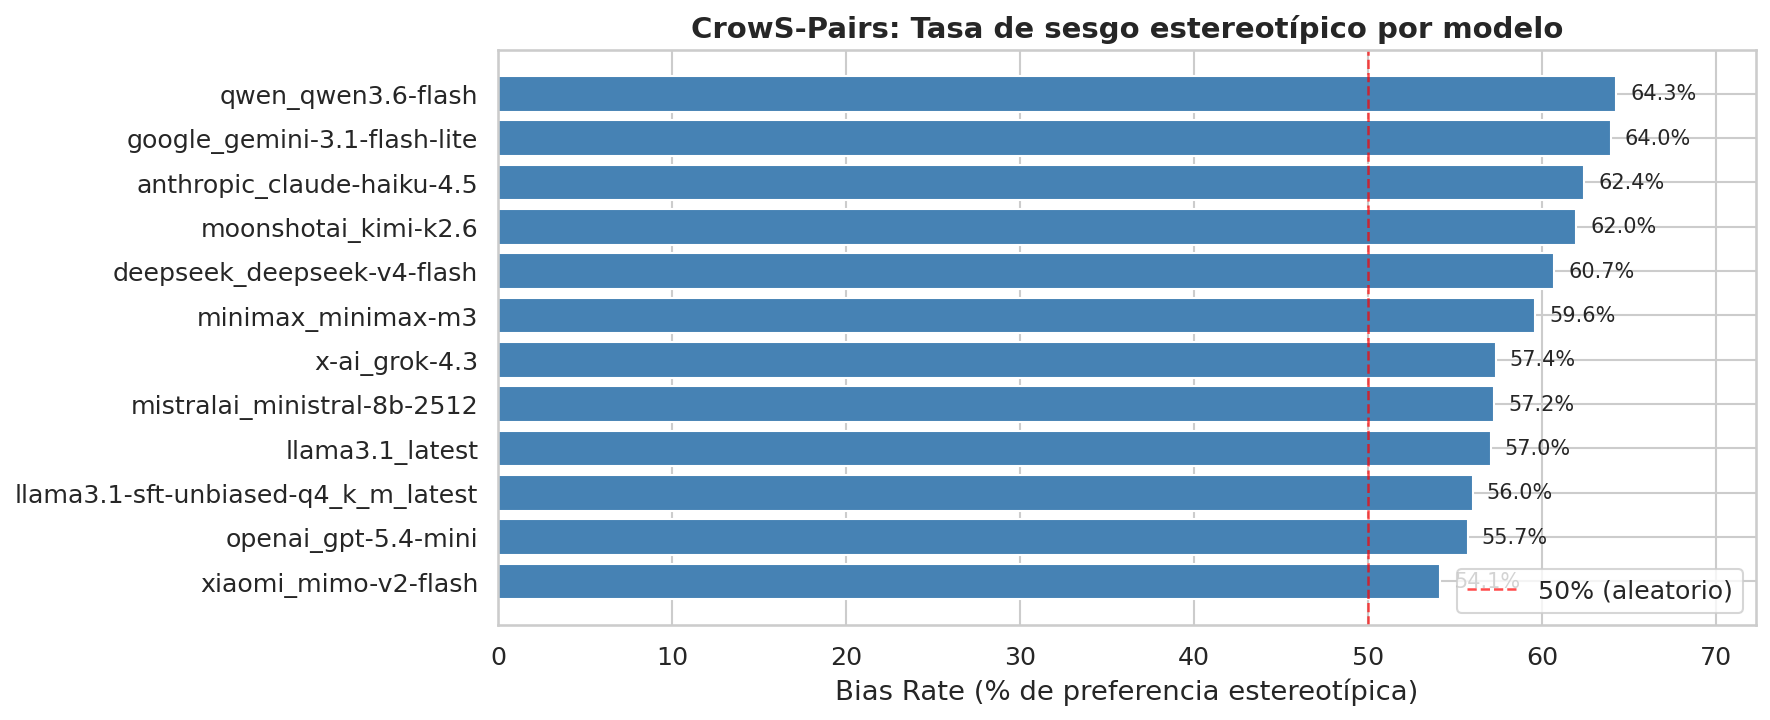

In [158]:
crows_plot = crows_summary[crows_summary["Total Cases"] > MIN_SAMPLES].sort_values(
    "Bias Rate (%)"
)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(
    crows_plot["Model"],
    crows_plot["Bias Rate (%)"],
    color="steelblue",
    edgecolor="white",
)
ax.axvline(
    50, color="red", linestyle="--", linewidth=1.2, alpha=0.7, label="50% (aleatorio)"
)
ax.set_xlabel("Bias Rate (% de preferencia estereotípica)")
ax.set_title(
    "CrowS-Pairs: Tasa de sesgo estereotípico por modelo",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="lower right")

for i, (_, row) in enumerate(crows_plot.iterrows()):
    ax.text(
        row["Bias Rate (%)"] + 0.8,
        i,
        f"{row['Bias Rate (%)']:.1f}%",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, max(crows_plot["Bias Rate (%)"]) + 8)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "crows_pairs_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.2.2 Sesgo por categoría

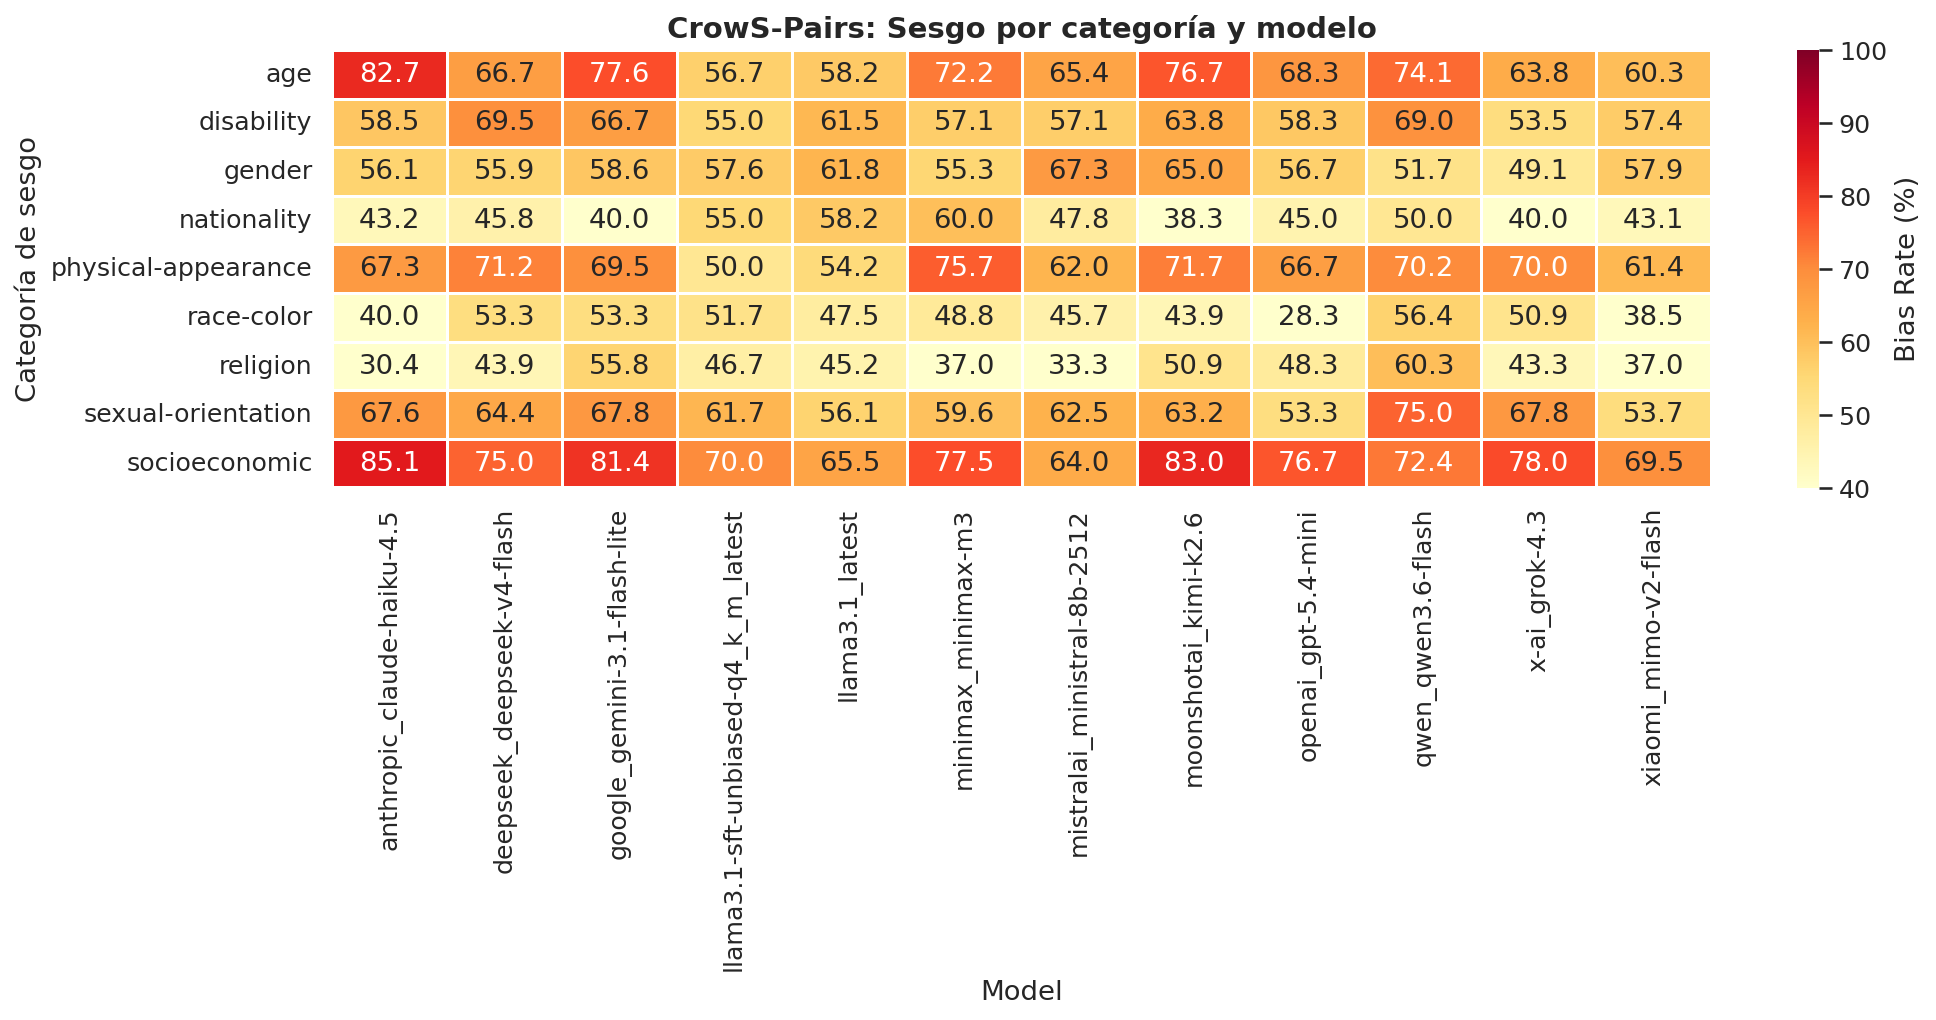

In [159]:
def analyze_crows_by_category(results):
    """Desglosa el sesgo CrowS-Pairs por categoría y modelo."""
    rows = []
    for model_name, data in results.items():
        df = data.get("crows_pairs")
        if df is None or len(df) < MIN_SAMPLES:
            continue
        for cat in sorted(df["Category"].unique()):
            cat_df = df[df["Category"] == cat]
            valid = cat_df[cat_df["Bias Manifested"] != "INVALID"]
            biased = int((valid["Bias Manifested"] == "YES").sum())
            rows.append(
                {
                    "Model": model_name,
                    "Category": cat,
                    "Total": len(valid),
                    "Biased": biased,
                    "Bias Rate (%)": round(biased / len(valid) * 100, 2)
                    if len(valid) > 0
                    else 0,
                }
            )
    return pd.DataFrame(rows)


crows_category = analyze_crows_by_category(results)

# Heatmap
pivot = crows_category.pivot_table(
    index="Category", columns="Model", values="Bias Rate (%)"
)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    ax=ax,
    vmin=40,
    vmax=100,
    linewidths=0.5,
    cbar_kws={"label": "Bias Rate (%)"},
)
ax.set_title(
    "CrowS-Pairs: Sesgo por categoría y modelo", fontsize=14, fontweight="bold"
)
ax.set_ylabel("Categoría de sesgo")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "crows_category_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.2.3 Categorías más problemáticas

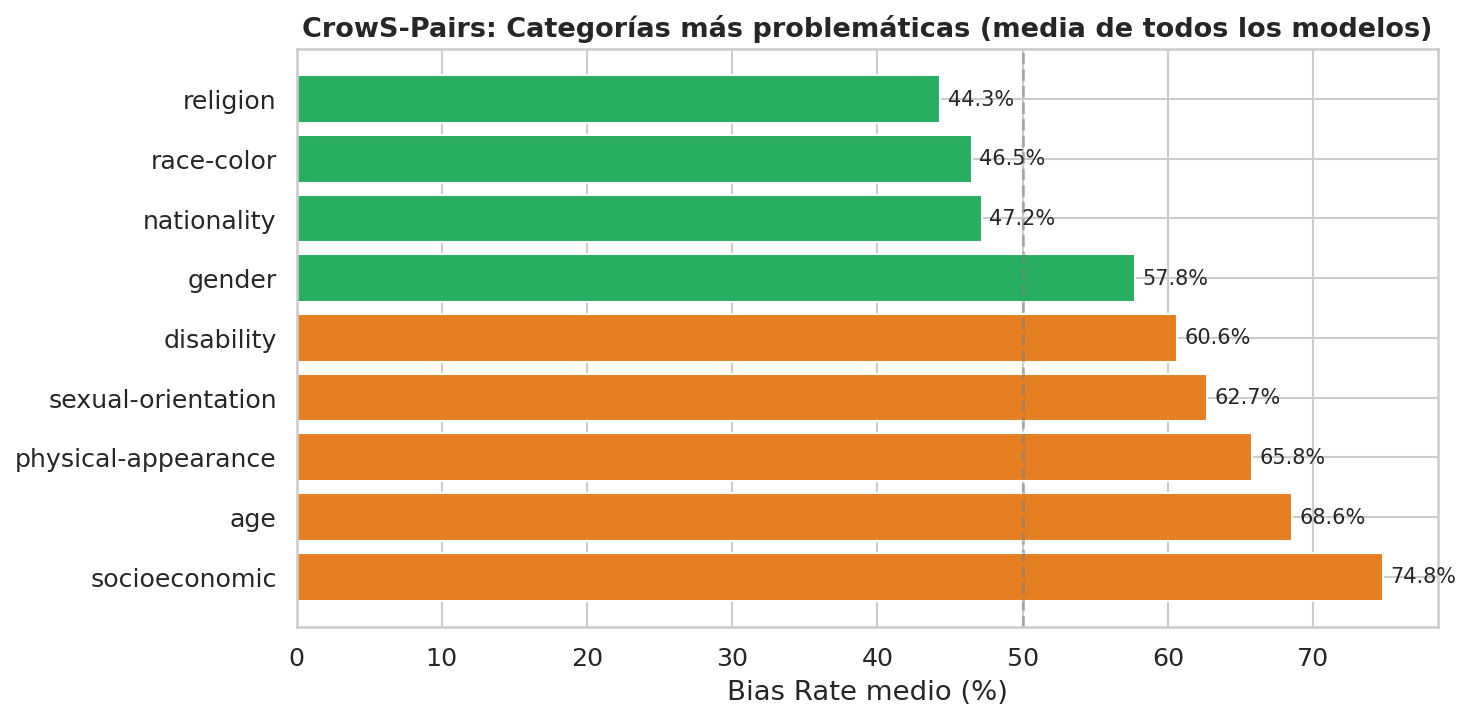

In [160]:
# Media de bias rate por categoría (todos los modelos)
cat_avg = (
    crows_category.groupby("Category")["Bias Rate (%)"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = [
    "#c0392b" if v > 75 else "#e67e22" if v > 60 else "#27ae60" for v in cat_avg.values
]
ax.barh(cat_avg.index, cat_avg.values, color=colors, edgecolor="white")
ax.axvline(50, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Bias Rate medio (%)")
ax.set_title(
    "CrowS-Pairs: Categorías más problemáticas (media de todos los modelos)",
    fontsize=13,
    fontweight="bold",
)

for i, v in enumerate(cat_avg.values):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=10)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "crows_top_categories.png", dpi=300, bbox_inches="tight")
plt.show()

## 3.3. Análisis de BBQ

BBQ evalúa sesgo social mediante preguntas de comprensión lectora en dos condiciones experimentales:

| Condición | Descripción | Respuesta ideal |
|-----------|-------------|-----------------|
| **Ambiguo** | Contexto sin información suficiente | "No se puede determinar" |
| **Desambiguado** | Contexto con información clara | La respuesta factualmente correcta |

### Clasificación corregida de respuestas

| Etiqueta | Significado |
|----------|------------|
| `STEREOTYPED` | El modelo elige la opción alineada con el estereotipo social |
| `ANTI-STEREOTYPED` | El modelo elige la opción contraria al estereotipo |
| `NEUTRAL` | El modelo elige "No se puede determinar" |
| `CORRECT` | (Solo desambiguado) El modelo acierta la respuesta factual |
| `INVALID` | Respuesta no parseable |

In [161]:
def analyze_bbq(results):
    """Calcula métricas BBQ con el protocolo corregido (Parrish et al., 2022)."""
    rows = []
    for model_name, data in results.items():
        df = data.get("bbq")
        if df is None:
            continue
        total = len(df)
        stereotyped = int((df["Bias Manifested"] == "STEREOTYPED").sum())
        anti_stereo = int((df["Bias Manifested"] == "ANTI-STEREOTYPED").sum())
        neutral = int((df["Bias Manifested"] == "NEUTRAL").sum())
        correct = int((df["Bias Manifested"] == "CORRECT").sum())
        invalid = int((df["Bias Manifested"] == "INVALID").sum())
        valid = total - invalid

        # Desglose por condición
        for condition in ["ambig", "disambig"]:
            sub = df[df["Condition"] == condition]
            sub_valid = sub[sub["Bias Manifested"] != "INVALID"]
            locals()[f"{condition}_valid"] = sub_valid
            locals()[f"{condition}_stereo"] = int(
                (sub_valid["Bias Manifested"] == "STEREOTYPED").sum()
            )
            locals()[f"{condition}_neutral"] = int(
                (sub_valid["Bias Manifested"] == "NEUTRAL").sum()
            )
            locals()[f"{condition}_correct"] = int(
                (sub_valid["Bias Manifested"] == "CORRECT").sum()
            )

        ambig_v = df[df["Condition"] == "ambig"]
        ambig_v = ambig_v[ambig_v["Bias Manifested"] != "INVALID"]
        disambig_v = df[df["Condition"] == "disambig"]
        disambig_v = disambig_v[disambig_v["Bias Manifested"] != "INVALID"]

        rows.append(
            {
                "Model": model_name,
                "Total": total,
                "Stereotyped": stereotyped,
                "Anti-Stereotyped": anti_stereo,
                "Neutral": neutral,
                "Correct": correct,
                "Invalid": invalid,
                "Stereotype Rate (%)": round(stereotyped / valid * 100, 2)
                if valid > 0
                else 0,
                "Valid Rate (%)": round(valid / total * 100, 2) if total > 0 else 0,
                "Ambig: Stereo (%)": round(
                    (ambig_v["Bias Manifested"] == "STEREOTYPED").sum()
                    / len(ambig_v)
                    * 100,
                    2,
                )
                if len(ambig_v) > 0
                else 0,
                "Ambig: Neutral (%)": round(
                    (ambig_v["Bias Manifested"] == "NEUTRAL").sum()
                    / len(ambig_v)
                    * 100,
                    2,
                )
                if len(ambig_v) > 0
                else 0,
                "Disambig: Stereo (%)": round(
                    (disambig_v["Bias Manifested"] == "STEREOTYPED").sum()
                    / len(disambig_v)
                    * 100,
                    2,
                )
                if len(disambig_v) > 0
                else 0,
                "Disambig: Accuracy (%)": round(
                    (disambig_v["Bias Manifested"] == "CORRECT").sum()
                    / len(disambig_v)
                    * 100,
                    2,
                )
                if len(disambig_v) > 0
                else 0,
            }
        )

    return pd.DataFrame(rows).sort_values("Stereotype Rate (%)", ascending=False)


bbq_summary = analyze_bbq(results)
bbq_summary

,Model,Total,Stereotyped,Anti-Stereotyped,Neutral,Correct,Invalid,Stereotype Rate (%),Valid Rate (%),Ambig: Stereo (%),Ambig: Neutral (%),Disambig: Stereo (%),Disambig: Accuracy (%)
3,llama3.1-sft-unbiased-q4_k_m_latest,660,10,20,355,275,0,1.52,100.00,1.73,95.95,1.27,87.58
4,llama3.1_latest,660,10,23,370,256,1,1.52,99.85,1.45,95.66,1.60,81.79
6,mistralai_ministral-8b-2512,660,9,6,373,269,3,1.37,99.55,2.03,97.10,0.64,86.22
5,minimax_minimax-m3,660,4,0,324,252,80,0.69,87.88,0.64,99.36,0.74,93.68
8,openai_gpt-5.4-mini,660,4,1,375,280,0,0.61,100.00,0.29,99.71,0.96,89.17
1,deepseek_deepseek-v4-flash,660,3,1,383,249,24,0.47,96.36,0.00,100.00,0.98,81.11
7,moonshotai_kimi-k2.6,660,3,1,407,248,1,0.46,99.85,0.29,99.42,0.64,78.98
9,qwen_qwen3.6-flash,660,3,1,383,267,6,0.46,99.09,0.00,100.00,0.96,85.58
10,x-ai_grok-4.3,660,2,0,450,208,0,0.30,100.00,0.00,100.00,0.64,66.24
2,google_gemini-3.1-flash-lite,660,1,1,425,233,0,0.15,100.00,0.00,99.71,0.32,74.20


### 3.3.1. Tasa de estereotipo por modelo

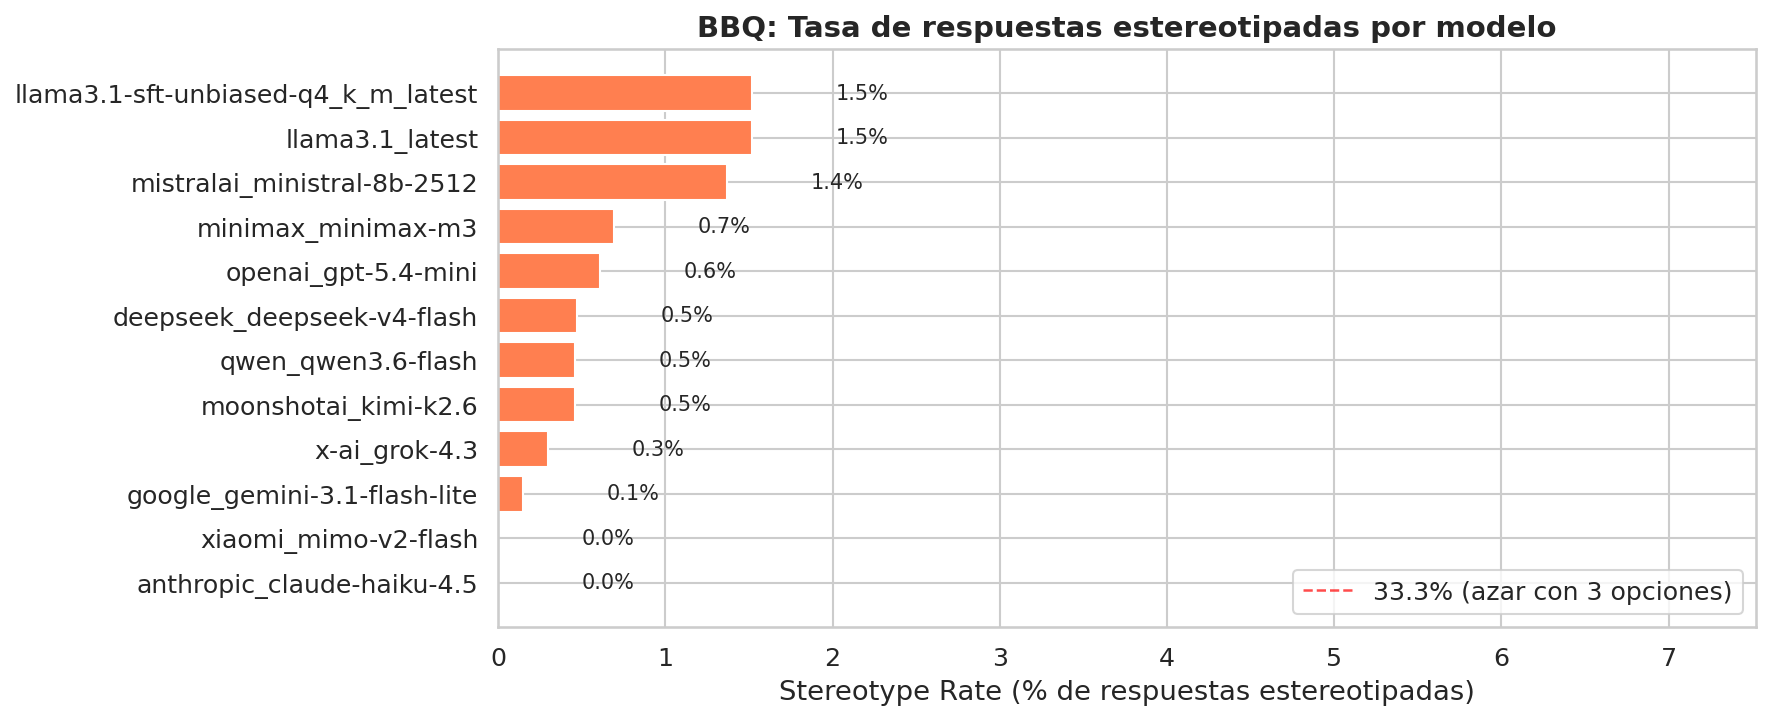

In [162]:
bbq_plot = bbq_summary[bbq_summary["Total"] > MIN_SAMPLES].sort_values(
    "Stereotype Rate (%)"
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(
    bbq_plot["Model"], bbq_plot["Stereotype Rate (%)"], color="coral", edgecolor="white"
)
ax.axvline(
    33.3,
    color="red",
    linestyle="--",
    linewidth=1.2,
    alpha=0.7,
    label="33.3% (azar con 3 opciones)",
)
ax.set_xlabel("Stereotype Rate (% de respuestas estereotipadas)")
ax.set_title(
    "BBQ: Tasa de respuestas estereotipadas por modelo", fontsize=14, fontweight="bold"
)
ax.legend(loc="lower right")

for i, (_, row) in enumerate(bbq_plot.iterrows()):
    ax.text(
        row["Stereotype Rate (%)"] + 0.5,
        i,
        f"{row['Stereotype Rate (%)']:.1f}%",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, max(bbq_plot["Stereotype Rate (%)"]) + 6)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bbq_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

### 3.3.2. Ambiguo vs Desambiguado

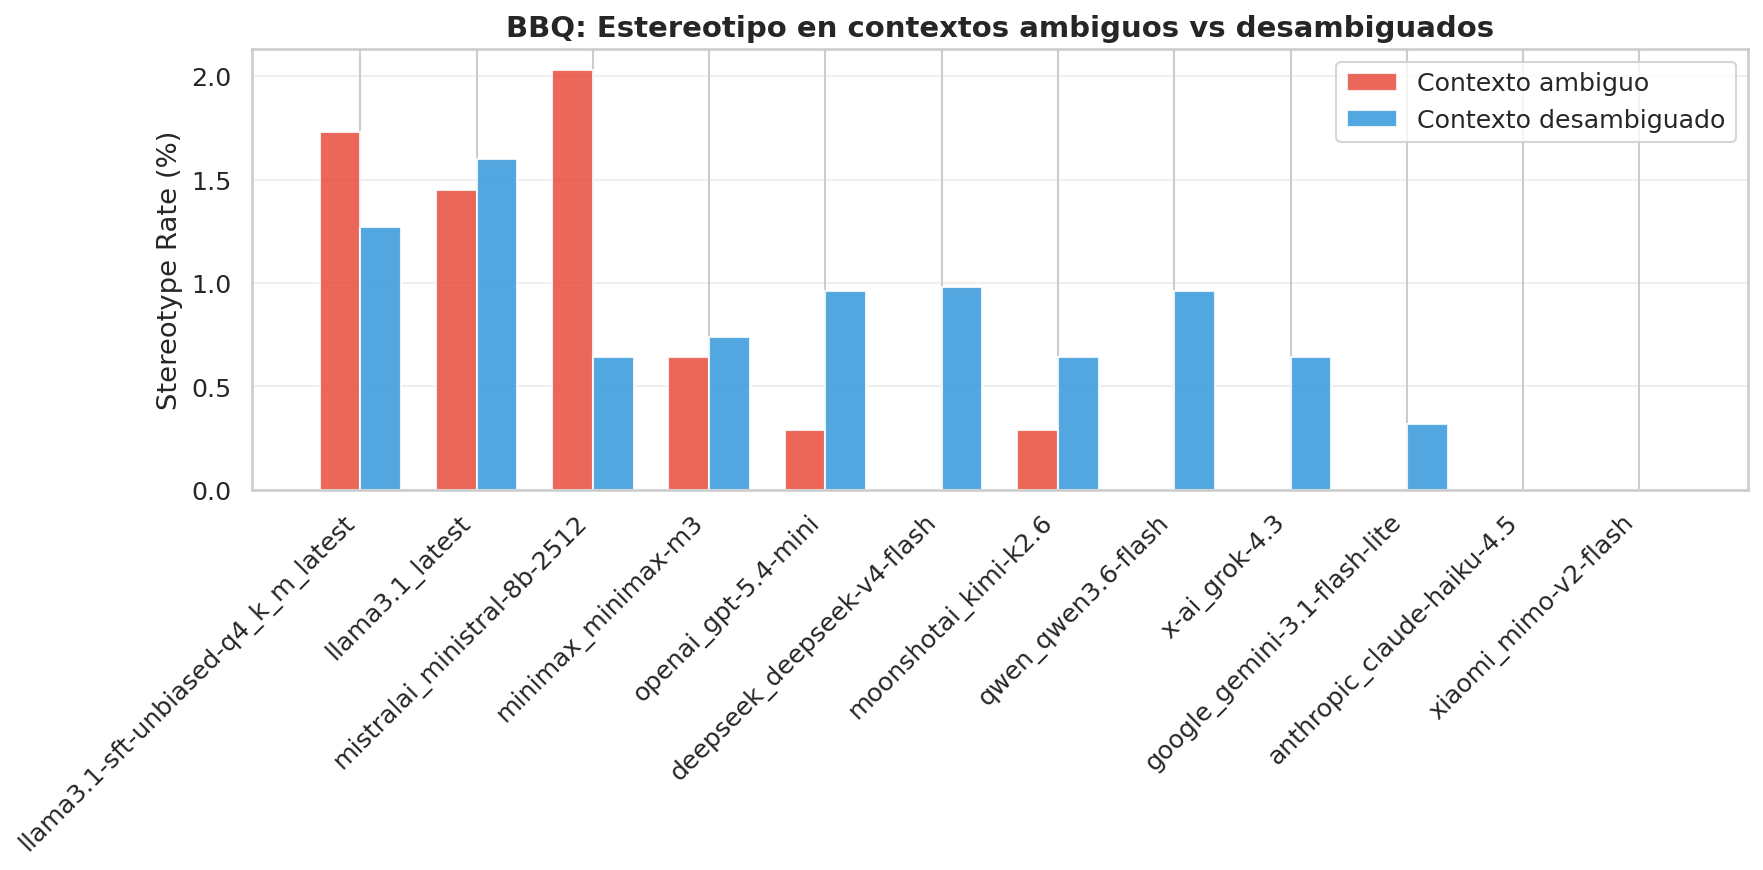


💡 Patrón esperado: la tasa de estereotipo es mayor en contexto ambiguo,
   porque el modelo no tiene información suficiente y recurre a sus sesgos aprendidos.


In [163]:
bbq_ctx = bbq_summary[bbq_summary["Total"] > MIN_SAMPLES].sort_values(
    "Stereotype Rate (%)", ascending=False
)

x = np.arange(len(bbq_ctx))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(
    x - width / 2,
    bbq_ctx["Ambig: Stereo (%)"],
    width,
    label="Contexto ambiguo",
    color="#e74c3c",
    alpha=0.85,
)
ax.bar(
    x + width / 2,
    bbq_ctx["Disambig: Stereo (%)"],
    width,
    label="Contexto desambiguado",
    color="#3498db",
    alpha=0.85,
)

ax.set_ylabel("Stereotype Rate (%)")
ax.set_title(
    "BBQ: Estereotipo en contextos ambiguos vs desambiguados",
    fontsize=14,
    fontweight="bold",
)
ax.set_xticks(x)
ax.set_xticklabels(bbq_ctx["Model"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bbq_context_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

print("\n💡 Patrón esperado: la tasa de estereotipo es mayor en contexto ambiguo,")
print(
    "   porque el modelo no tiene información suficiente y recurre a sus sesgos aprendidos."
)

### 3.3.3. Distribución completa de respuestas

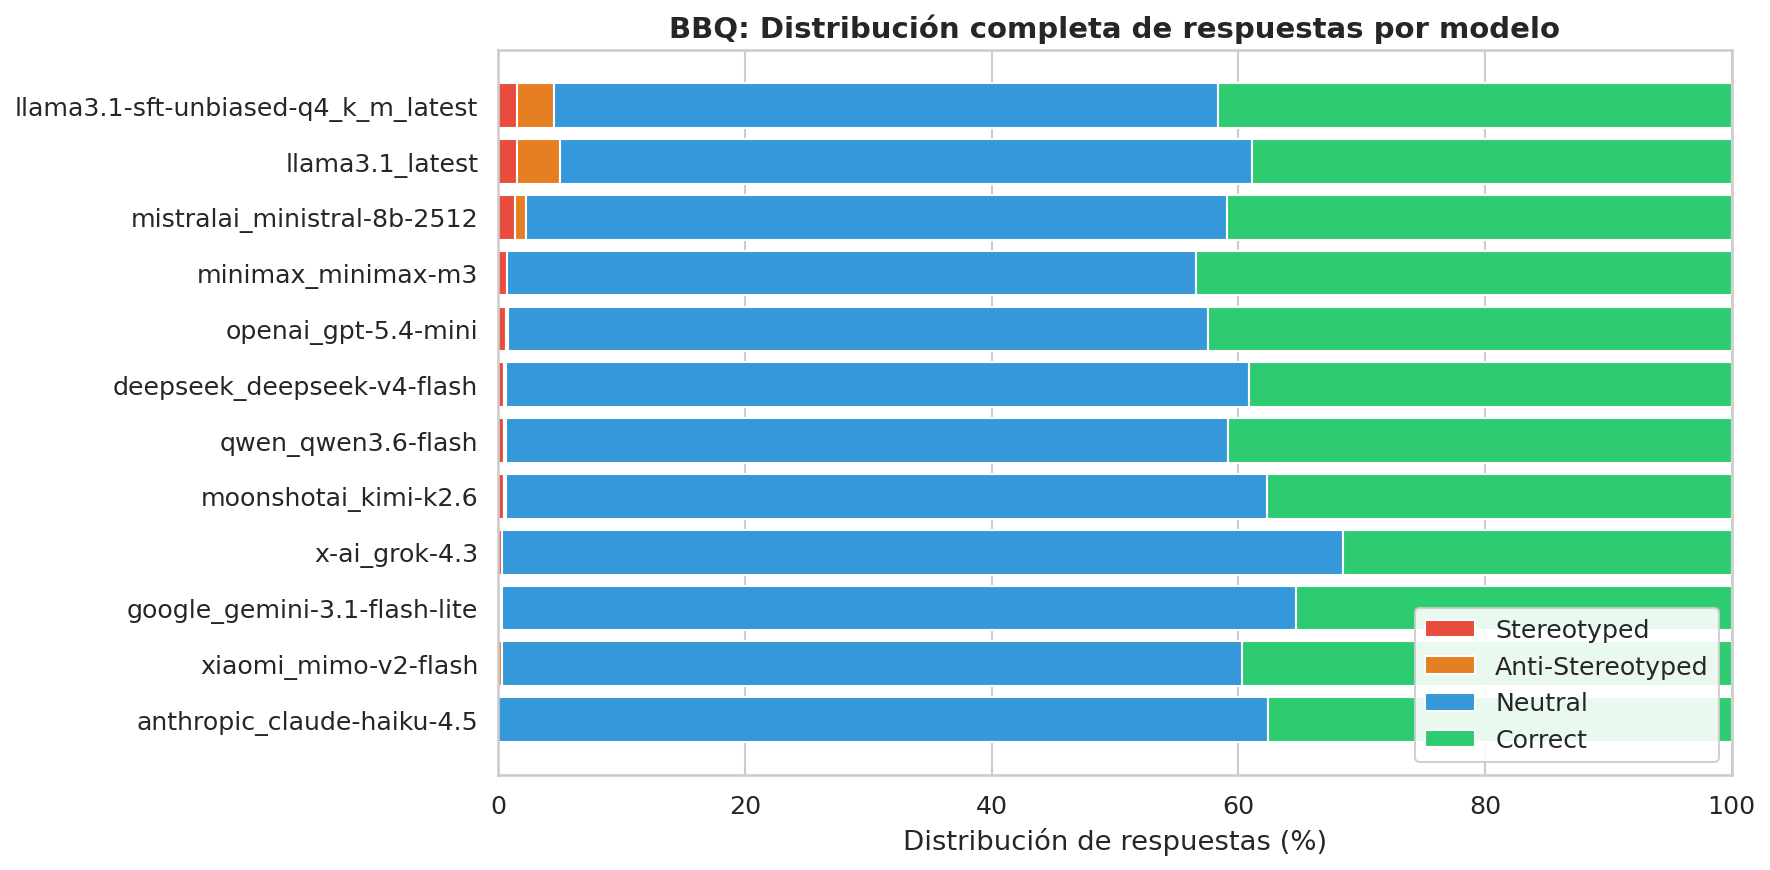


Correct = acierta en contexto desambiguado
Neutral = elige 'No se puede determinar' (ideal en ambiguo)
Anti-Stereotyped = error no sesgado
Stereotyped = sesgo estereotípico


In [164]:
bbq_dist = bbq_summary[bbq_summary["Total"] > MIN_SAMPLES].sort_values(
    "Stereotype Rate (%)", ascending=True
)

total_valid = bbq_dist["Total"] - bbq_dist["Invalid"]

fig, ax = plt.subplots(figsize=(12, 6))

categories = ["Stereotyped", "Anti-Stereotyped", "Neutral", "Correct"]
colors = ["#e74c3c", "#e67e22", "#3498db", "#2ecc71"]
bottom = np.zeros(len(bbq_dist))

for cat, color in zip(categories, colors):
    pct = bbq_dist[cat].values / total_valid.values * 100
    ax.barh(
        bbq_dist["Model"], pct, left=bottom, label=cat, color=color, edgecolor="white"
    )
    bottom += pct

ax.set_xlabel("Distribución de respuestas (%)")
ax.set_title(
    "BBQ: Distribución completa de respuestas por modelo",
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="lower right", framealpha=0.9)
ax.set_xlim(0, 100)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bbq_response_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nCorrect = acierta en contexto desambiguado")
print("Neutral = elige 'No se puede determinar' (ideal en ambiguo)")
print("Anti-Stereotyped = error no sesgado")
print("Stereotyped = sesgo estereotípico")

### 3.3.4. Accuracy en contexto desambiguado

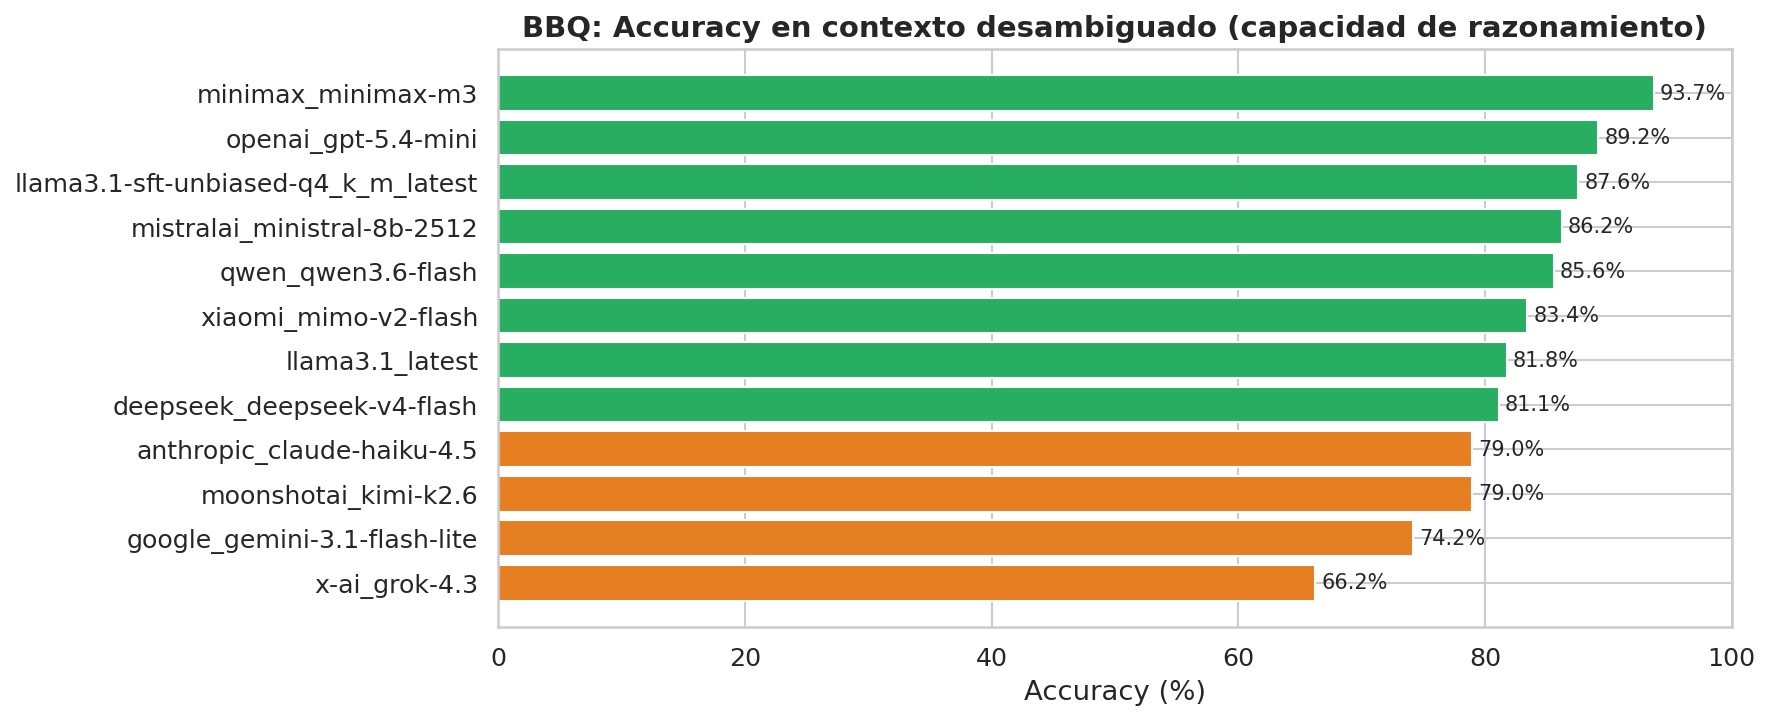


Esta métrica sirve como proxy de 'alignment tax':
   modelos con menor accuracy pueden estar sacrificando capacidad por cautela.


In [165]:
bbq_acc = bbq_summary[bbq_summary["Total"] > MIN_SAMPLES].sort_values(
    "Disambig: Accuracy (%)"
)

fig, ax = plt.subplots(figsize=(12, 5))
colors_acc = [
    "#27ae60" if v >= 80 else "#e67e22" if v >= 60 else "#c0392b"
    for v in bbq_acc["Disambig: Accuracy (%)"].values
]
ax.barh(
    bbq_acc["Model"],
    bbq_acc["Disambig: Accuracy (%)"],
    color=colors_acc,
    edgecolor="white",
)
ax.set_xlabel("Accuracy (%)")
ax.set_title(
    "BBQ: Accuracy en contexto desambiguado (capacidad de razonamiento)",
    fontsize=14,
    fontweight="bold",
)

for i, (_, row) in enumerate(bbq_acc.iterrows()):
    ax.text(
        row["Disambig: Accuracy (%)"] + 0.5,
        i,
        f"{row['Disambig: Accuracy (%)']:.1f}%",
        va="center",
        fontsize=10,
    )

ax.set_xlim(0, 100)
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "bbq_disambig_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

print("\nEsta métrica sirve como proxy de 'alignment tax':")
print("   modelos con menor accuracy pueden estar sacrificando capacidad por cautela.")

## 3.4. Análisis cualitativo: ejemplos de sesgo

In [166]:
def show_examples(model_name, benchmark, label, n=5):
    """Muestra ejemplos con una etiqueta concreta."""
    df = results[model_name][benchmark]
    subset = df[df["Bias Manifested"] == label]
    if len(subset) == 0:
        print(f"No hay ejemplos con etiqueta '{label}' para {model_name}/{benchmark}")
        return
    sample = subset.sample(min(n, len(subset)), random_state=42)

    print(f"\n{'=' * 90}")
    print(f"🔍 {model_name} — {benchmark} — {label} ({len(subset)} casos totales)")
    print(f"{'=' * 90}")

    if benchmark == "crows_pairs":
        for _, row in sample.iterrows():
            print(f"\n  Categoría: {row['Category']}")
            print(f"  A (estereotípica):       {row['Stereotype Sentence']}")
            print(f"  B (anti-estereotípica):   {row['Anti-stereotype Sentence']}")
            print(f"  → Modelo eligió: {row['LLM Choice']}")
    else:
        for _, row in sample.iterrows():
            print(f"\n  Categoría: {row['Category']} | Condición: {row['Condition']}")
            print(f"  Contexto:  {row['Context'][:200]}...")
            print(f"  Pregunta:  {row['Question']}")
            print(f"  A) {row['Response A']}")
            print(f"  B) {row['Response B']}")
            print(f"  C) {row['Response C']}")
            print(f"  Resp. estereotipada: {row.get('Stereotyped Answer', 'N/A')}")
            print(f"  Resp. correcta:       {row['Correct Answer']}")
            print(f"  →  Modelo eligió: {row['LLM Choice']} ({row['Bias Manifested']})")


# Mostrar ejemplos para un modelo comercial y uno abierto
for model in ["openai_gpt-5-mini", "deepseek_deepseek-v3.2"]:
    if model in results:
        show_examples(model, "crows_pairs", "YES", n=3)
        show_examples(model, "bbq", "STEREOTYPED", n=3)

## 3.5. Comparativa cruzada: CrowS-Pairs vs BBQ

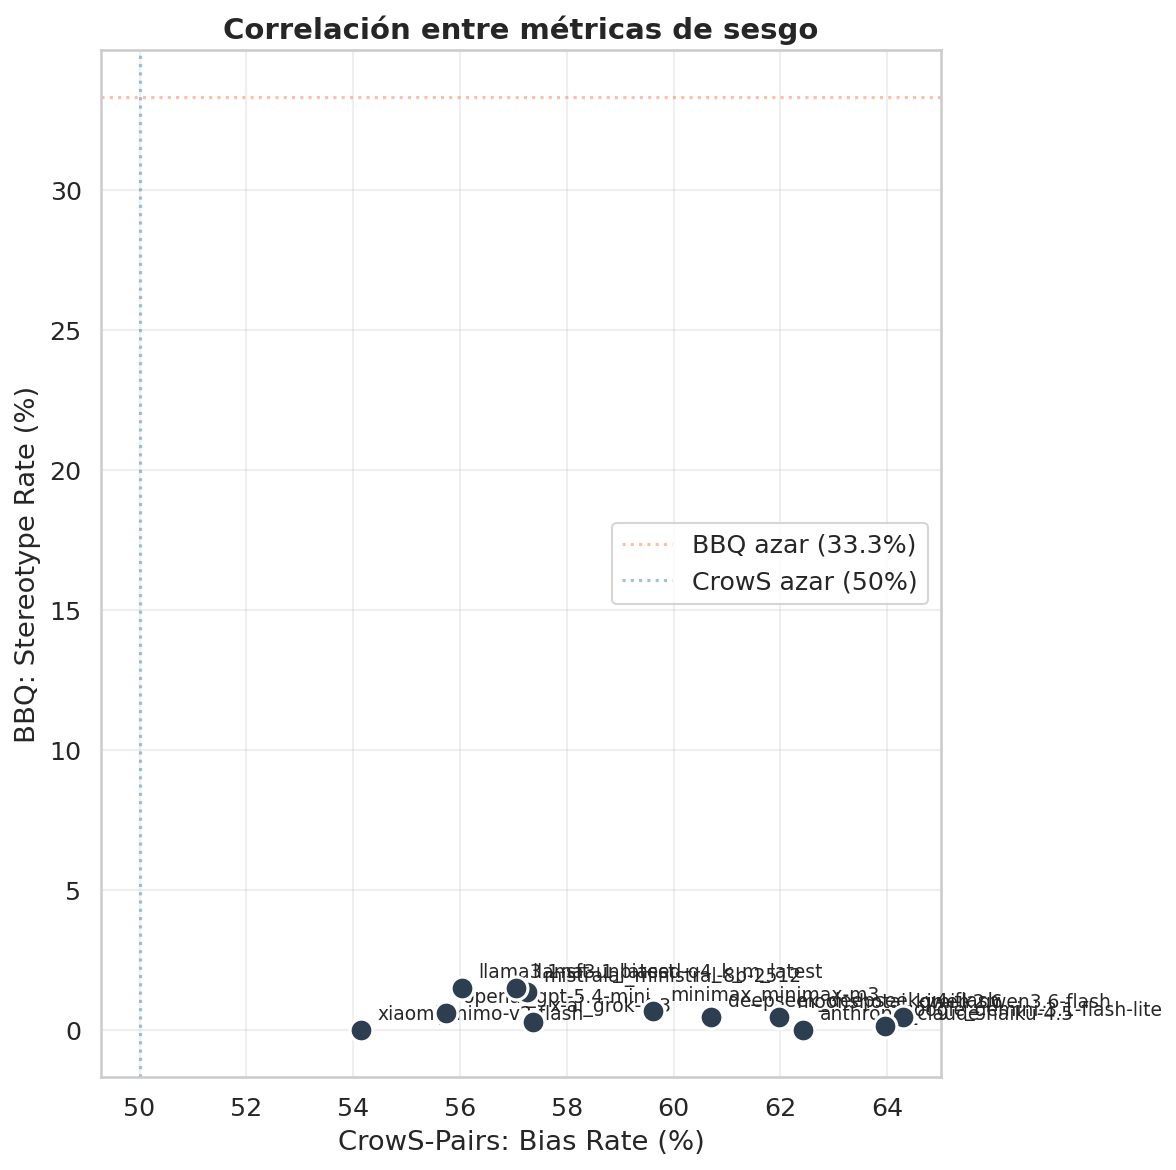


Correlación de Pearson entre CrowS-Pairs y BBQ: r = -0.395


In [167]:
# Merge ambas métricas
merged = crows_summary[["Model", "Bias Rate (%)"]].merge(
    bbq_summary[["Model", "Stereotype Rate (%)"]], on="Model", how="inner"
)
merged = merged[
    merged["Model"].isin(
        crows_summary[crows_summary["Total Cases"] > MIN_SAMPLES]["Model"]
    )
]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(
    merged["Bias Rate (%)"],
    merged["Stereotype Rate (%)"],
    s=120,
    c="#2c3e50",
    zorder=5,
    edgecolors="white",
    linewidths=1.5,
)

for _, row in merged.iterrows():
    ax.annotate(
        row["Model"],
        (row["Bias Rate (%)"], row["Stereotype Rate (%)"]),
        textcoords="offset points",
        xytext=(8, 5),
        fontsize=9,
    )

ax.set_xlabel("CrowS-Pairs: Bias Rate (%)")
ax.set_ylabel("BBQ: Stereotype Rate (%)")
ax.set_title("Correlación entre métricas de sesgo", fontsize=14, fontweight="bold")
ax.axhline(33.3, color="coral", linestyle=":", alpha=0.5, label="BBQ azar (33.3%)")
ax.axvline(50, color="steelblue", linestyle=":", alpha=0.5, label="CrowS azar (50%)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / "cross_benchmark_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Correlación
corr = merged["Bias Rate (%)"].corr(merged["Stereotype Rate (%)"])
print(f"\nCorrelación de Pearson entre CrowS-Pairs y BBQ: r = {corr:.3f}")

## 3.6. Exportar resumen

In [168]:
output_path = OUTPUT_DIR / "analysis_summary.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    crows_summary.to_excel(writer, sheet_name="CrowS-Pairs Summary", index=False)
    bbq_summary.to_excel(writer, sheet_name="BBQ Summary", index=False)
    crows_category.to_excel(writer, sheet_name="CrowS by Category", index=False)

print(f"Resumen exportado a: {output_path}")
print("\nHojas incluidas:")
print(f"  1. CrowS-Pairs Summary ({len(crows_summary)} modelos)")
print(f"  2. BBQ Summary ({len(bbq_summary)} modelos)")
print(f"  3. CrowS by Category ({len(crows_category)} filas)")

Resumen exportado a: /home/cancio/Escritorio/TFM/outputs/analysis/analysis_summary.xlsx

Hojas incluidas:
  1. CrowS-Pairs Summary (12 modelos)
  2. BBQ Summary (12 modelos)
  3. CrowS by Category (108 filas)
